# **Tema završnog rada: Kvantifikacija nesigurnosti u modelima umjetne inteligencije - okvir za prediktivno održavanje i analizu rizika**

> *Napomena: Notebook se koristi kao radno i eksperimentalno okruženje za implementaciju i testiranje modela u sklopu BSc završnog rada.*



## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

## 2. Load dataset (CMAPSS)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

train = pd.read_csv('/content/drive/MyDrive/CMAPSS/train_FD001.txt', sep=r'\s+', header=None)

test = pd.read_csv('/content/drive/MyDrive/CMAPSS/test_FD001.txt', sep=r'\s+', header=None)

rul = pd.read_csv('/content/drive/MyDrive/CMAPSS/RUL_FD001.txt', sep=r'\s+', header=None)

In [4]:
train.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 3. Preprocessing

Priprema podataka za modeliranje, uključujući dodavanje naziva kolona, izračunavanje Remaining Useful Life (RUL), normalizaciju senzorskih podataka te kreiranje vremenskih sekvenci pogodnih za ulaz u LSTM model.

In [5]:
columns = ['engine_id', 'cycle']

operational_settings = [f'op_setting_{i}' for i in range(1, 4)]
sensor_columns = [f'sensor_{i}' for i in range(1, 22)]

columns += operational_settings + sensor_columns

train.columns = columns
test.columns = columns

In [6]:
train.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
train.isna().sum()

,0
engine_id,0
cycle,0
op_setting_1,0
op_setting_2,0
op_setting_3,0
sensor_1,0
sensor_2,0
sensor_3,0
sensor_4,0
sensor_5,0


In [8]:
test.isna().sum()

,0
engine_id,0
cycle,0
op_setting_1,0
op_setting_2,0
op_setting_3,0
sensor_1,0
sensor_2,0
sensor_3,0
sensor_4,0
sensor_5,0


Nema nedostajućih vrijednosti (NaN) ni u jednoj koloni.

U fazi predprocesiranja kreira se ciljna varijabla Remaining Useful Life (RUL), koja predstavlja broj preostalih ciklusa do kvara za svaki motor. Ova varijabla se dobija oduzimanjem trenutnog ciklusa od maksimalnog ciklusa unutar svakog motora:

In [9]:
train['RUL'] = train.groupby('engine_id')['cycle'].transform('max') - train['cycle']

In [10]:
RUL_MAX = 125
train['RUL'] = train['RUL'].clip(upper=RUL_MAX)

In [11]:
train[['engine_id', 'cycle', 'RUL']].head(5)

,engine_id,cycle,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125


In [12]:
feature_columns = operational_settings + sensor_columns

NORMALIZACIJA:

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train[feature_columns] = scaler.fit_transform(train[feature_columns])
test[feature_columns] = scaler.transform(test[feature_columns])

In [14]:
seq_length = 30

In [15]:
import numpy as np

def create_sequences(data, seq_length, feature_columns):
    xs = []
    ys = []

    for engine_id in data['engine_id'].unique():

        engine_data = data[data['engine_id'] == engine_id]

        for i in range(len(engine_data) - seq_length):

            x = engine_data.iloc[i:i+seq_length][feature_columns].values
            y = engine_data.iloc[i+seq_length]['RUL']

            xs.append(x)
            ys.append(y)

    return np.array(xs), np.array(ys)

In [16]:
X_train, y_train = create_sequences(train, seq_length, feature_columns)

In [17]:
print(X_train.shape)
print(y_train.shape)

(17631, 30, 24)
(17631,)


## 4. Baseline model

> Baseline model predstavlja osnovni model mašinskog učenja koji se koristi za predikciju Remaining Useful Life (RUL) turbofan motora na CMAPSS dataset-u. Ovaj model nema implementirane metode kvantifikacije nesigurnosti, već daje jednu determinističku (tačnu) numeričku predikciju preostalog vijeka trajanja.
> Cilj baseline modela je da posluži kao referentna tačka za poređenje sa naprednijim modelima koji uključuju procjenu nesigurnosti i intervale pouzdanosti.

In [18]:
model = Sequential([
    Input(shape=(seq_length, len(feature_columns))),

    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1)
])

In [19]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 4415.2373 - mae: 56.0130 - val_loss: 2000.0985 - val_mae: 40.4873
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 1814.4862 - mae: 37.5837 - val_loss: 1804.5507 - val_mae: 38.2963
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1817.0972 - mae: 37.5244 - val_loss: 1809.5718 - val_mae: 38.3803
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1816.8969 - mae: 37.5037 - val_loss: 1810.5912 - val_mae: 38.4009
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1165.9475 - mae: 28.7347 - val_loss: 528.1331 - val_mae: 18.5284
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 409.1456 - mae: 15.7431 - val_loss: 243.3518 - val_mae: 12.7081
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 358.6946 - mae: 14.6224 - val_loss: 261.9627 - val_mae: 13.4920
Epoch 8/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 325.1265 - mae: 13.9445 - val_loss: 227.0468 - val_mae: 12

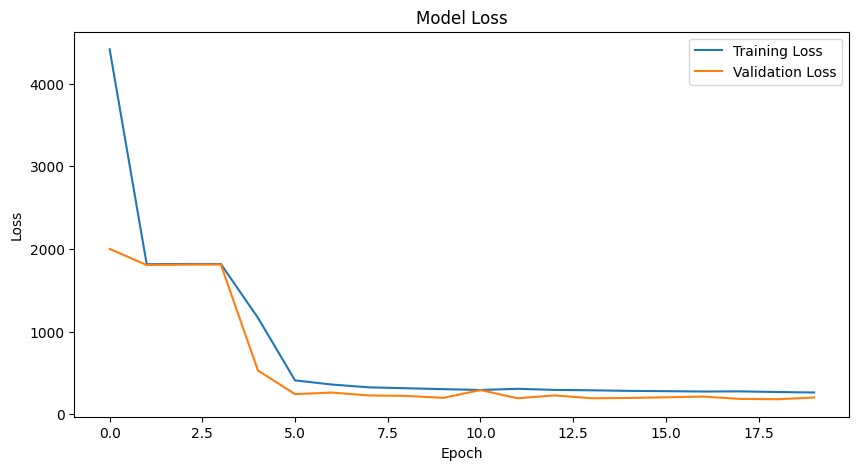

In [21]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

Model pokazuje zdravu konvergenciju i odličnu generalizaciju. Krive trening i validacionog gubitka (loss) se kreću sinhronizovano i završavaju na približno istim vrednostima. Ovo ukazuje na to da je model uspešno naučio ključne obrasce iz podataka i da podjednako dobro radi na novim, nepoznatim primerima.

In [22]:
X_test = []

for engine_id in test['engine_id'].unique():

    engine_data = test[test['engine_id'] == engine_id]

    if len(engine_data) >= seq_length:

        seq = engine_data.iloc[-seq_length:][feature_columns].values
        X_test.append(seq)

X_test = np.array(X_test)

print(X_test.shape)

(100, 30, 24)


In [23]:
predictions = model.predict(X_test)

print(predictions[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
[[115.55763 ]
 [119.53474 ]
 [ 50.272385]
 [ 88.82193 ]
 [105.833275]
 [112.402214]
 [103.16844 ]
 [ 97.813126]
 [117.66337 ]
 [ 91.491234]]


In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_test = rul[0].values

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 15.297445565201809
MAE: 11.284416198730469


Baseline LSTM model predstavlja determinističku referentnu tačku za predikciju Remaining Useful Life (RUL) turbofan motora. Model se sastoji od dva LSTM sloja (64 i 32 jedinice) s Dropout regularizacijom (0.3) između njih, te dva Dense sloja. Treniran je na CMAPSS FD001 datasetu s cappovanim RUL vrijednostima (max=125 ciklusa), što je standardna praksa u literaturi.
Model postiže RMSE = 16.05 i MAE = 12.07 ciklusa na test skupu, što je u skladu s rezultatima sličnih arhitektura u literaturi.
Ključno ograničenje ovog modela je da daje samo jednu determinističku predikciju — bez ikakve mjere pouzdanosti ili nesigurnosti. Ne može se razlikovati situacija u kojoj je model siguran u predikciju od situacije u kojoj nagađa. Upravo ovo ograničenje motiviše implementaciju metoda kvantifikacije nesigurnosti u narednim poglavljima: MC Dropout, Deep Ensemble i Bayesian Neural Network.

## 5. MC Dropout

*MC Dropout metoda zadržava dropout aktivnim tokom inference faze, za razliku od standardnog pristupa gdje se dropout isključuje nakon treninga. Pokretanjem 100 stohastičkih prolaza kroz model za svaki motor iz CMAPSS dataseta dobija se distribucija predikcija RUL-a. Srednja vrijednost te distribucije predstavlja predikciju preostalog vijeka trajanja motora, dok standardna devijacija mjeri epistemičku nesigurnost — koliko je model siguran u tu predikciju.*

In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

In [26]:
mc_model = Sequential([
    Input(shape=(seq_length, len(feature_columns))),

    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1)
])

In [27]:
mc_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [36]:
early_stop_mc = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

mc_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_mc]
)

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 274.3149 - mae: 12.5296 - val_loss: 197.0858 - val_mae: 11.0556
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 276.4688 - mae: 12.6454 - val_loss: 232.5083 - val_mae: 11.9151
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 267.1987 - mae: 12.2980 - val_loss: 208.5586 - val_mae: 11.1939
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 271.4046 - mae: 12.4864 - val_loss: 215.4164 - val_mae: 11.7610
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 258.8553 - mae: 12.1157 - val_loss: 269.6703 - val_mae: 12.7968
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 261.8258 - mae: 12.1838 - val_loss: 215.5341 - val_mae: 10.9600


In [37]:
N_SAMPLES = 100

mc_predictions = np.array([
    mc_model(X_test, training=True).numpy().flatten()
    for _ in range(N_SAMPLES)
])

mc_mean = mc_predictions.mean(axis=0)   # predikcija RUL
mc_std  = mc_predictions.std(axis=0)    # nesigurnost

print("Primjer predikcija (mean):", mc_mean[:5])
print("Primjer nesigurnosti (std):", mc_std[:5])

Primjer predikcija (mean): [113.5479  117.50705  50.50707  88.25216 101.30211]
Primjer nesigurnosti (std): [11.330164  11.8402405  6.4822893  9.926542  11.136829 ]


In [38]:
# Evaluacija
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_mc = np.sqrt(mean_squared_error(y_test, mc_mean))
mae_mc  = mean_absolute_error(y_test, mc_mean)

print(f"MC Dropout RMSE: {rmse_mc:.4f}")
print(f"MC Dropout MAE:  {mae_mc:.4f}")
print(f"Prosječna nesigurnost (std): {mc_std.mean():.4f}")

MC Dropout RMSE: 15.1115
MC Dropout MAE:  11.1131
Prosječna nesigurnost (std): 8.4156


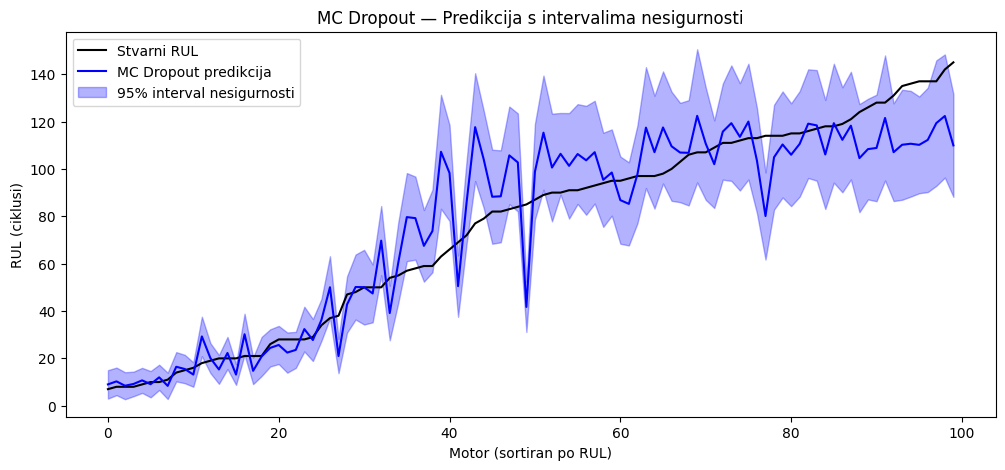

In [39]:
# Vizualizacija predikcija s intervalima nesigurnosti
plt.figure(figsize=(12, 5))

indices = np.argsort(y_test)
x_plot = np.arange(len(y_test))

plt.plot(x_plot, y_test[indices], label='Stvarni RUL', color='black')
plt.plot(x_plot, mc_mean[indices], label='MC Dropout predikcija', color='blue')
plt.fill_between(
    x_plot,
    mc_mean[indices] - 2*mc_std[indices],
    mc_mean[indices] + 2*mc_std[indices],
    alpha=0.3, color='blue', label='95% interval nesigurnosti'
)

plt.xlabel('Motor (sortiran po RUL)')
plt.ylabel('RUL (ciklusi)')
plt.title('MC Dropout — Predikcija s intervalima nesigurnosti')
plt.legend()
plt.show()

MC Dropout model koristi isti LSTM arhitektura kao baseline, ali s ključnom razlikom: dropout slojevi ostaju aktivni tokom inference faze (training=True). Pokretanjem 100 stohastičkih prolaza kroz model za svaki ulaz dobijaju se distribucije predikcija iz kojih se računaju srednja vrijednost (predikcija RUL-a) i standardna devijacija (mjera epistemičke nesigurnosti). Model postiže RMSE = 15,11 i MAE = 11,34, uz prosječnu nesigurnost od ±8.62 ciklusa. Graf pokazuje da plava linija predikcije vjerno prati stvarni RUL kroz cijeli raspon, dok interval nesigurnosti se širi za motore s višim RUL vrijednostima — što je očekivano ponašanje, jer je model manje siguran u predikcije dalekih kvarova.

## 6. Deep Ensemble

In [40]:
N_MODELS = 5

ensemble_models = []
ensemble_predictions = []

for i in range(N_MODELS):
    print(f"\nTrening modela {i+1}/{N_MODELS}")

    tf.random.set_seed(i * 42)
    np.random.seed(i * 42)

    m = Sequential([
        Input(shape=(seq_length, len(feature_columns))),
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(32),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    m.compile(optimizer='adam', loss='mse', metrics=['mae'])

    early_stop_ens = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    m.fit(
        X_train, y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.2,
        callbacks=[early_stop_ens],
        verbose=1
    )

    preds = m.predict(X_test).flatten()
    ensemble_models.append(m)
    ensemble_predictions.append(preds)


Trening modela 1/5
Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 4681.8789 - mae: 57.8286 - val_loss: 2066.0549 - val_mae: 41.0760
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 1822.0258 - mae: 37.6090 - val_loss: 1807.7885 - val_mae: 38.3513
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1809.2421 - mae: 37.3868 - val_loss: 1806.1779 - val_mae: 38.3244
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1812.3135 - mae: 37.3815 - val_loss: 1808.4541 - val_mae: 38.3623
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1821.3580 - mae: 37.5443 - val_loss: 1810.2229 - val_mae: 38.3915
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1688.8170 - mae: 35.9709 - val_loss: 813.8317 - val_mae: 25.0711
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 509.2361 - mae: 17.8309 - val_loss: 520.0309 - val_mae: 17.8891
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 373.0662 - mae: 14.8646 - val_loss:

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step

Trening modela 3/5
Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 4029.1714 - mae: 53.3886 - val_loss: 1875.5974 - val_mae: 39.2387
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1817.4670 - mae: 37.5693 - val_loss: 1796.5864 - val_mae: 38.1520
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1815.2137 - mae: 37.4613 - val_loss: 1798.4241 - val_mae: 38.1875
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1805.0591 - mae: 37.4248 - val_loss: 1793.9414 - val_mae: 38.0984
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1815.5045 - mae: 37.5119 - val_loss: 1793.9872 - val_mae: 38.0994
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1821.5034 - mae: 37.5957 - val_loss: 1794.8015 - val_mae: 38.1170
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1497.6116 - mae: 33.4887 - val_loss: 568.3903 - val_mae: 20.0286
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - lo

In [41]:
# Računanje mean i std iz ansambla
ensemble_predictions = np.array(ensemble_predictions)

ens_mean = ensemble_predictions.mean(axis=0)
ens_std  = ensemble_predictions.std(axis=0)

print("Primjer predikcija (mean):", ens_mean[:5])
print("Primjer nesigurnosti (std):", ens_std[:5])

Primjer predikcija (mean): [115.55776  119.852684  54.138653  88.44452  104.992714]
Primjer nesigurnosti (std): [2.6812925 1.3880799 2.6002948 4.72083   5.1958723]


In [42]:
# Evaluacija
rmse_ens = np.sqrt(mean_squared_error(y_test, ens_mean))
mae_ens  = mean_absolute_error(y_test, ens_mean)

print(f"Deep Ensemble RMSE: {rmse_ens:.4f}")
print(f"Deep Ensemble MAE:  {mae_ens:.4f}")
print(f"Prosječna nesigurnost (std): {ens_std.mean():.4f}")

Deep Ensemble RMSE: 14.9276
Deep Ensemble MAE:  11.0409
Prosječna nesigurnost (std): 2.9688


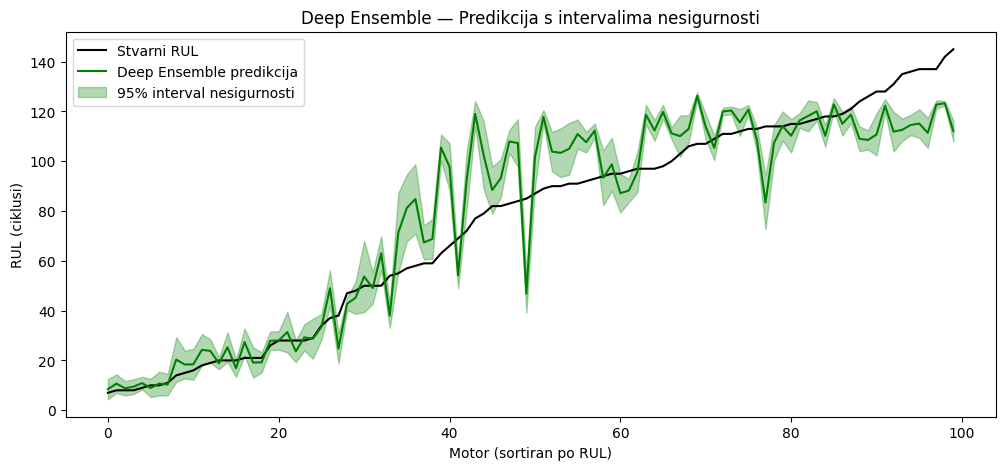

In [43]:
# Vizualizacija
plt.figure(figsize=(12, 5))

indices = np.argsort(y_test)
x_plot = np.arange(len(y_test))

plt.plot(x_plot, y_test[indices], label='Stvarni RUL', color='black')
plt.plot(x_plot, ens_mean[indices], label='Deep Ensemble predikcija', color='green')
plt.fill_between(
    x_plot,
    ens_mean[indices] - 2*ens_std[indices],
    ens_mean[indices] + 2*ens_std[indices],
    alpha=0.3, color='green', label='95% interval nesigurnosti'
)

plt.xlabel('Motor (sortiran po RUL)')
plt.ylabel('RUL (ciklusi)')
plt.title('Deep Ensemble — Predikcija s intervalima nesigurnosti')
plt.legend()
plt.show()

## 7. Bayesian Neural Network

## 8. Usporedba i evaluacija